# Term Deposit Subscription Prediction (Bank Marketing)
## Professional Portfolio Project
**Objective:** Predict whether a bank customer will subscribe to a term deposit.

## Step 1 — Import Libraries
In this step, we import libraries for data analysis, visualization, machine learning, evaluation, and explainable AI.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc

import shap


C:\Users\YS\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2 — Load Dataset

In [6]:
df = pd.read_csv(r'G:\Data Science\DS 27\Data\bank-full.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())

Shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None
age          0
job          0
marital      0
education    0
default      0


## Step 3 — Exploratory Data Analysis (EDA)

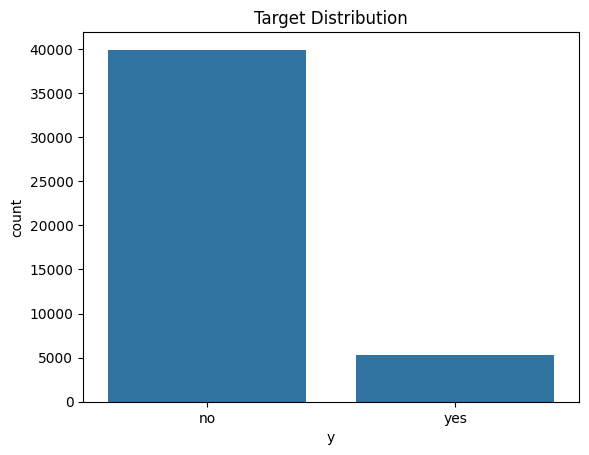

In [8]:
df['y'].value_counts()

sns.countplot(data=df, x='y')
plt.title('Target Distribution')
plt.show()

## Step 4 — Encode Categorical Features

In [9]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


## Step 5 — Feature Engineering & Train/Test Split

In [10]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 6 — Logistic Regression

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)


## Step 7 — Random Forest

In [12]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


## Step 8 — Model Evaluation

In [13]:
print("Logistic Regression F1 Score:", f1_score(y_test, lr_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_pred))

print("\nConfusion Matrix (Random Forest)")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))


Logistic Regression F1 Score: 0.3185483870967742
Random Forest F1 Score: 0.5047353760445682

Confusion Matrix (Random Forest)
[[7701  251]
 [ 638  453]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.64      0.42      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043



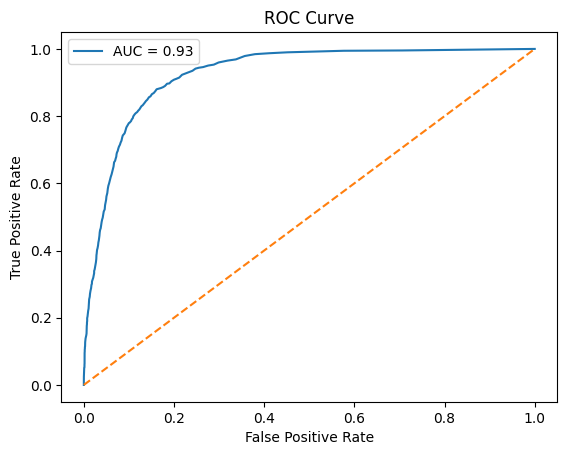

In [14]:
rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Step 9 — Explainable AI using SHAP

Prediction 1


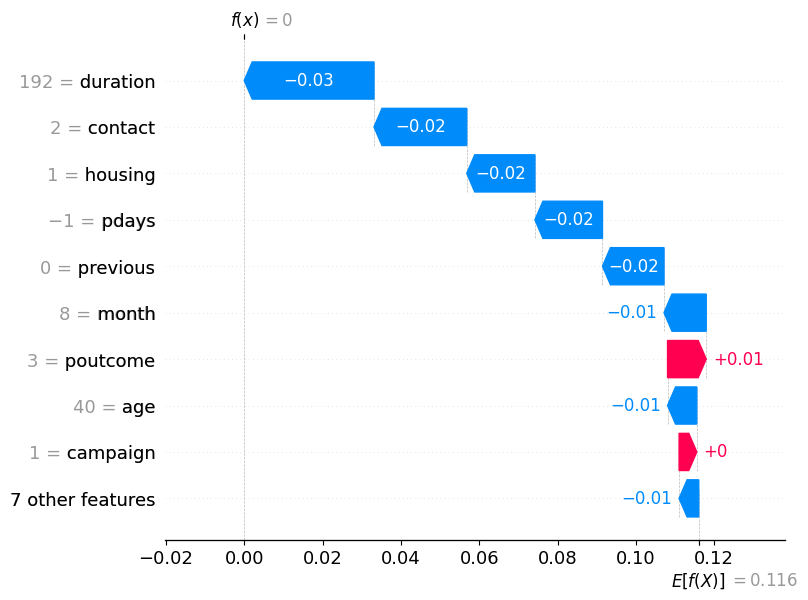

Prediction 2


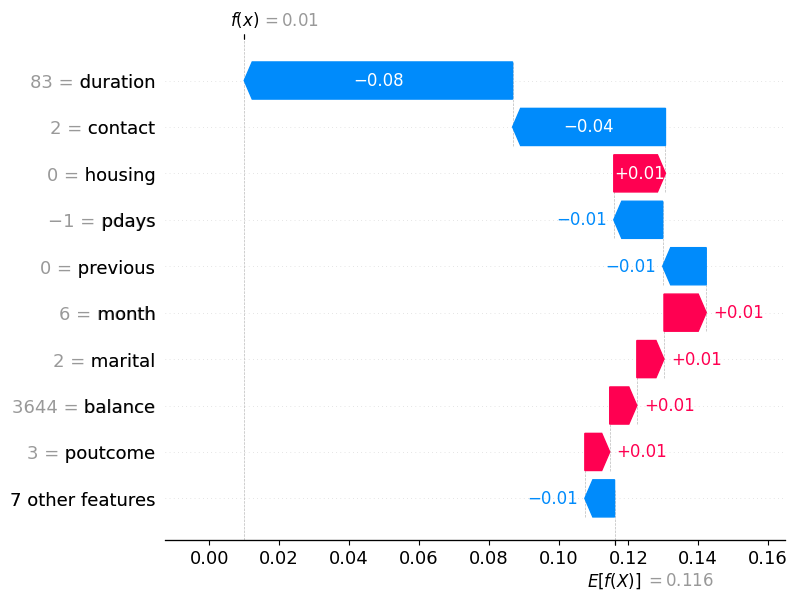

Prediction 3


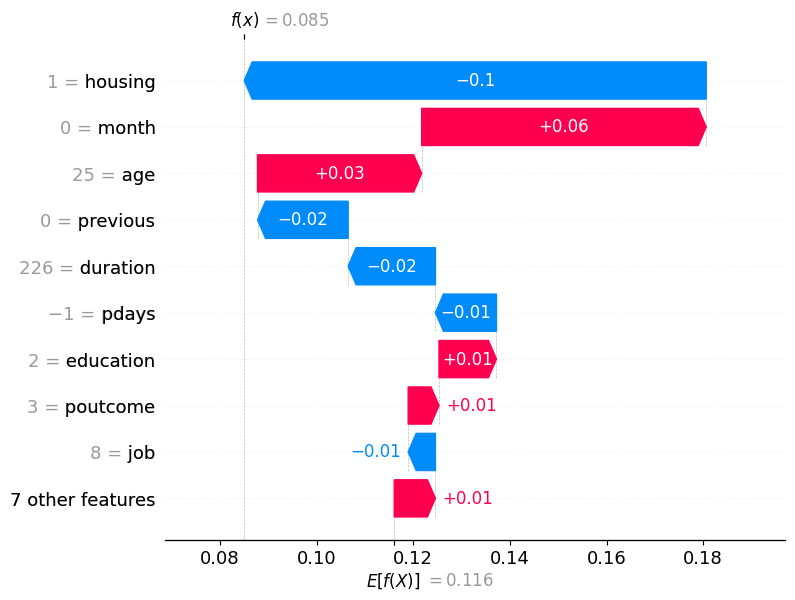

Prediction 4


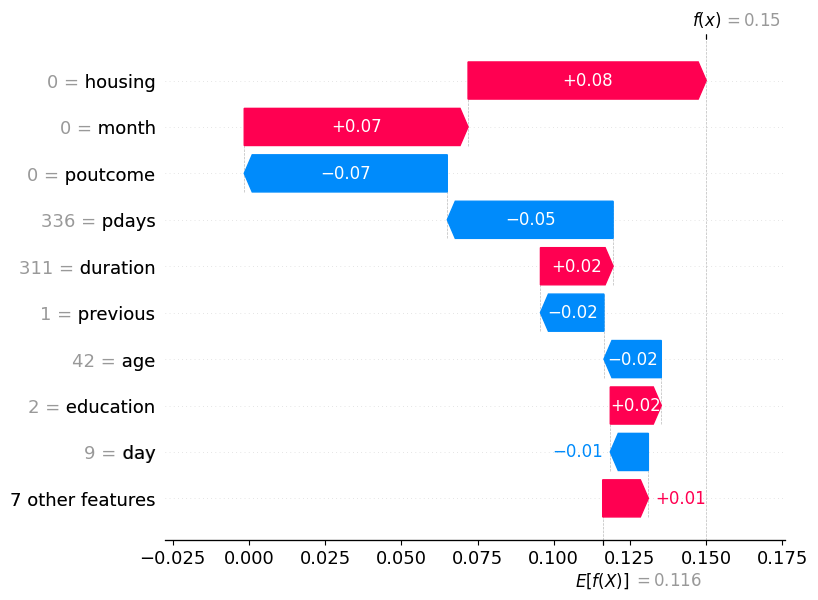

Prediction 5


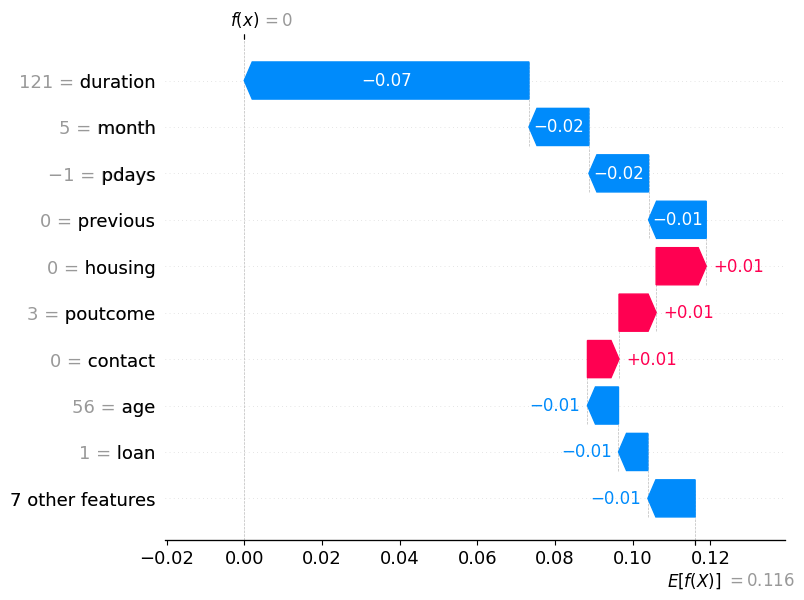

In [15]:
explainer = shap.TreeExplainer(rf)

sample = X_test.iloc[:5]

shap_values = explainer.shap_values(sample)

for i in range(5):
    print(f"Prediction {i+1}")
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[:,:,1][i],
            base_values=explainer.expected_value[1],
            data=sample.iloc[i],
            feature_names=sample.columns
        )
    )


## Business Insights

- Customers contacted longer (`duration`) tend to subscribe more.
- Campaign strategy influences customer behavior.
- Previous campaign outcomes can impact future subscriptions.
- Machine Learning helps marketing teams target customers more efficiently.


## Final Conclusion

In this project, we:
- Loaded and explored the Bank Marketing dataset.
- Encoded categorical features.
- Built Logistic Regression and Random Forest models.
- Evaluated models using Confusion Matrix, F1 Score, and ROC Curve.
- Applied SHAP Explainable AI to interpret 5 predictions.
- Generated business insights from customer behavior patterns.
